# Importing Libaraies and Loading datasets


In [7]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option("display.max_columns", None)

# chart style
sns.set_style("whitegrid")

In [8]:
# load datasets
customers = pd.read_csv("../data/customers.csv")
orders = pd.read_csv("../data/orders.csv")
support = pd.read_csv("../data/support_tickets.csv")
web = pd.read_csv("../data/web_events_snapshot.csv")
churn = pd.read_csv("../data/churn_labels.csv")
intervention = pd.read_csv("../data/intervention_history.csv")

# quick check
print(customers.shape)
print(orders.shape)
print(support.shape)
print(web.shape)
print(churn.shape)
print(intervention.shape)

(2400, 9)
(10009, 10)
(1921, 8)
(2400, 10)
(2400, 4)
(2400, 5)


In [9]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
support["ticket_date"] = pd.to_datetime(support["ticket_date"])

print("datasets loaded")

datasets loaded


# Schema inspection


In [10]:
datasets = {
    "customers": customers,
    "orders": orders,
    "support": support,
    "web": web,
    "churn": churn,
    "intervention": intervention
}

for name, df in datasets.items():

    print("\n", "="*50)
    print(name.upper())
    print("="*50)

    print(df.shape)
    print(df.info())

    display(df.head())


CUSTOMERS
(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          2400 non-null   object        
 1   signup_date          2400 non-null   datetime64[ns]
 2   city_tier            2400 non-null   object        
 3   age_group            2400 non-null   object        
 4   acquisition_channel  2400 non-null   object        
 5   loyalty_tier         1014 non-null   object        
 6   preferred_category   2400 non-null   object        
 7   skin_type            1999 non-null   object        
 8   marketing_consent    2400 non-null   object        
dtypes: datetime64[ns](1), object(8)
memory usage: 168.9+ KB
None


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes



ORDERS
(10009, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       10009 non-null  object        
 1   customer_id    10009 non-null  object        
 2   order_date     10009 non-null  datetime64[ns]
 3   category       10009 non-null  object        
 4   quantity       10009 non-null  int64         
 5   gross_amount   10009 non-null  float64       
 6   discount_pct   10009 non-null  float64       
 7   delivery_days  10009 non-null  int64         
 8   returned       10009 non-null  int64         
 9   rating         9929 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 782.1+ KB
None


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0



SUPPORT
(1921, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticket_id         1921 non-null   object        
 1   customer_id       1921 non-null   object        
 2   ticket_date       1921 non-null   datetime64[ns]
 3   issue_type        1921 non-null   object        
 4   support_channel   1921 non-null   object        
 5   resolution_hours  1921 non-null   float64       
 6   sentiment_score   1921 non-null   float64       
 7   reopened          1921 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 120.2+ KB
None


...

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9



CHURN
(2400, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     2400 non-null   object
 1   snapshot_date   2400 non-null   object
 2   churn_next_60d  2400 non-null   int64 
 3   split           2400 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.1+ KB
None


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train



INTERVENTION
(2400, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             2400 non-null   object
 1   snapshot_date           2400 non-null   object
 2   last_campaign_received  2400 non-null   object
 3   last_campaign_cost      2400 non-null   int64 
 4   manual_priority_bucket  2400 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.9+ KB
None


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


# data quality audit


Missing Values : customers
              missing_count  missing_percent
loyalty_tier           1386            57.75
skin_type               401            16.71

Missing Values : orders
        missing_count  missing_percent
rating             80              0.8

Missing Values : support
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Missing Values : web
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Missing Values : churn
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Missing Values : intervention
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Orders duplicates: 0
Duplicate-like orders: 12
Future orders: 1872


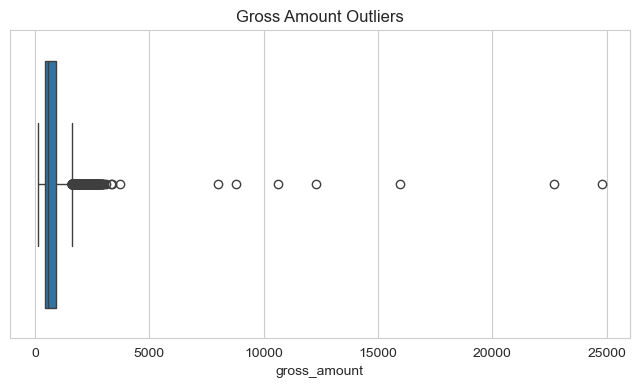

Duplicate-like records count: 12
Original matching records:


C:\Users\thanu\AppData\Local\Temp\ipykernel_4740\3045961844.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dup_orders['base_order_id'] = dup_orders['order_id'].str.replace('_DUP', '', regex=False)


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
600,ORD008249,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2620,ORD002124,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3533,ORD002862,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3601,ORD002916,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3674,ORD002970,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


In [19]:
# missing values
for name, df in datasets.items():

    print("\n" + "="*50)
    print("Missing Values :", name)
    print("="*50)

    missing = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_percent":
        round((df.isnull().sum()/len(df))*100, 2)
    })

    print(
        missing[
            missing["missing_count"] > 0
        ]
    )

# duplicate rows
print("\nOrders duplicates:",
      orders.duplicated().sum())

# duplicate-like order ids
dup_orders = orders[
    orders["order_id"]
    .str.contains("_DUP")
]

print("Duplicate-like orders:",
      dup_orders.shape[0])

# future leakage records
snapshot_date = pd.to_datetime(
    "2025-09-30"
)

future_orders = orders[
    orders["order_date"]
    > snapshot_date
]

print("Future orders:",
      future_orders.shape[0])

# outlier chart
plt.figure(figsize=(8,4))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Gross Amount Outliers")

plt.show()



# Check duplicate-like records in orders
dup_orders = orders[orders['order_id'].str.contains('_DUP', na=False)]

print("Duplicate-like records count:", dup_orders.shape[0])
dup_orders.head()

# Compare with original order ids
dup_orders['base_order_id'] = dup_orders['order_id'].str.replace('_DUP', '', regex=False)

comparison = orders[
    orders['order_id'].isin(dup_orders['base_order_id'])
]

print("Original matching records:")
comparison.head()

In [20]:
# Convert order_date to datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

snapshot_date = pd.Timestamp('2025-09-30')

# Post snapshot orders
post_snapshot_orders = orders[
    orders['order_date'] > snapshot_date
]

print("Post-snapshot orders count:", post_snapshot_orders.shape[0])

post_snapshot_orders[['order_id', 'customer_id', 'order_date']].head()

Post-snapshot orders count: 1872


,order_id,customer_id,order_date
7,ORD008129,CUST00002,2025-10-24
8,ORD008130,CUST00002,2025-10-26
15,ORD008132,CUST00005,2025-10-29
16,ORD008131,CUST00005,2025-11-19
22,ORD008133,CUST00006,2025-10-06


In [21]:
# Invalid ratings
invalid_ratings = orders[
    (orders['rating'] < 1) | (orders['rating'] > 5)
]

print("Invalid ratings:", invalid_ratings.shape[0])

# Negative monetary values
negative_amounts = orders[
    orders['gross_amount'] < 0
]

print("Negative gross amounts:", negative_amounts.shape[0])

# Delivery day anomalies
invalid_delivery = orders[
    orders['delivery_days'] <= 0
]

print("Invalid delivery days:", invalid_delivery.shape[0])

# Sentiment score range
invalid_sentiment = support[
    (support['sentiment_score'] < -1) |
    (support['sentiment_score'] > 1)
]

print("Invalid sentiment scores:", invalid_sentiment.shape[0])

Invalid ratings: 0
Negative gross amounts: 0
Invalid delivery days: 0
Invalid sentiment scores: 0


In [22]:
print("Orders Date Range:")
print(orders['order_date'].min())
print(orders['order_date'].max())

support['ticket_date'] = pd.to_datetime(support['ticket_date'])

print("\nSupport Ticket Date Range:")
print(support['ticket_date'].min())
print(support['ticket_date'].max())

print("\nSnapshot dates in churn labels:")
print(churn['snapshot_date'].unique())

print("\nSnapshot dates in web data:")
print(web['snapshot_date'].unique())

Orders Date Range:
2024-01-09 00:00:00
2025-11-29 00:00:00

Support Ticket Date Range:
2024-01-13 00:00:00
2025-09-30 00:00:00

Snapshot dates in churn labels:
['2025-09-30']

Snapshot dates in web data:
['2025-09-30']


# join validation

In [12]:
master = customers.merge(
    churn,
    on="customer_id",
    how="left"
)

master = master.merge(
    web,
    on="customer_id",
    how="left"
)

master = master.merge(
    intervention,
    on="customer_id",
    how="left"
)

print(master.shape)

display(master.head())

(2400, 25)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date_x,churn_next_60d,split,snapshot_date_y,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,2025-09-30,1,4,0,0,0,2,0,20,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,2025-09-30,8,31,4,2,3,0,0,0,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,2025-09-30,1,3,0,0,0,0,0,26,2025-09-30,none,18,high
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,2025-09-30,1,6,0,0,0,0,0,14,2025-09-30,free_shipping,40,high
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,2025-09-30,18,95,4,1,1,3,1,9,2025-09-30,welcome_offer,18,medium


In [23]:
# Row counts before joins
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support:", support.shape)

# Unique customer ids
print("Unique customers in customers:",
      customers['customer_id'].nunique())

print("Unique customers in support:",
      support['customer_id'].nunique())

# Missing joins
missing_support = customers[
    ~customers['customer_id'].isin(support['customer_id'])
]

print("Customers without support tickets:",
      missing_support.shape[0])

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Unique customers in customers: 2400
Unique customers in support: 1247
Customers without support tickets: 1153


# Churn Distribution and Demographics

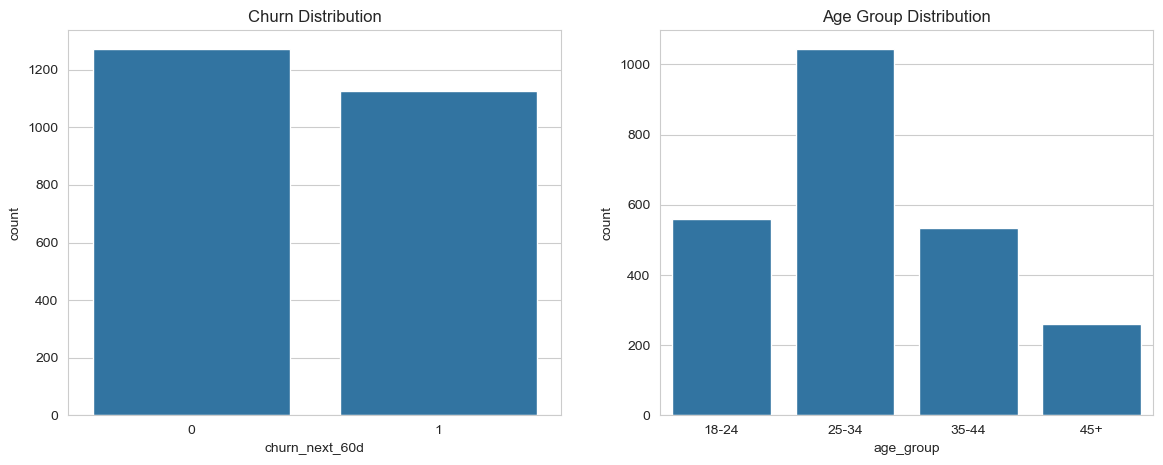

In [13]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(
    data=churn,
    x="churn_next_60d",
    ax=axes[0]
)

axes[0].set_title("Churn Distribution")

sns.countplot(
    data=customers,
    x="age_group",
    ax=axes[1]
)

axes[1].set_title("Age Group Distribution")

plt.show()

# Order and Monetary Analysis

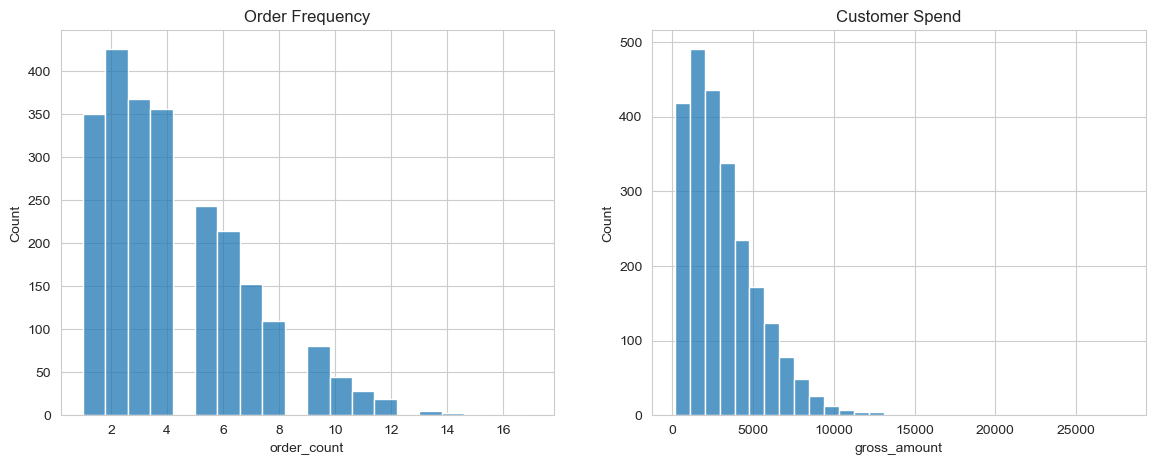

In [14]:
orders_per_customer = (
    orders.groupby("customer_id")
    ["order_id"]
    .count()
    .reset_index(name="order_count")
)

customer_spend = (
    orders.groupby("customer_id")
    ["gross_amount"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(
    orders_per_customer["order_count"],
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Order Frequency")

sns.histplot(
    customer_spend["gross_amount"],
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Customer Spend")

plt.show()

# Support, Web activity

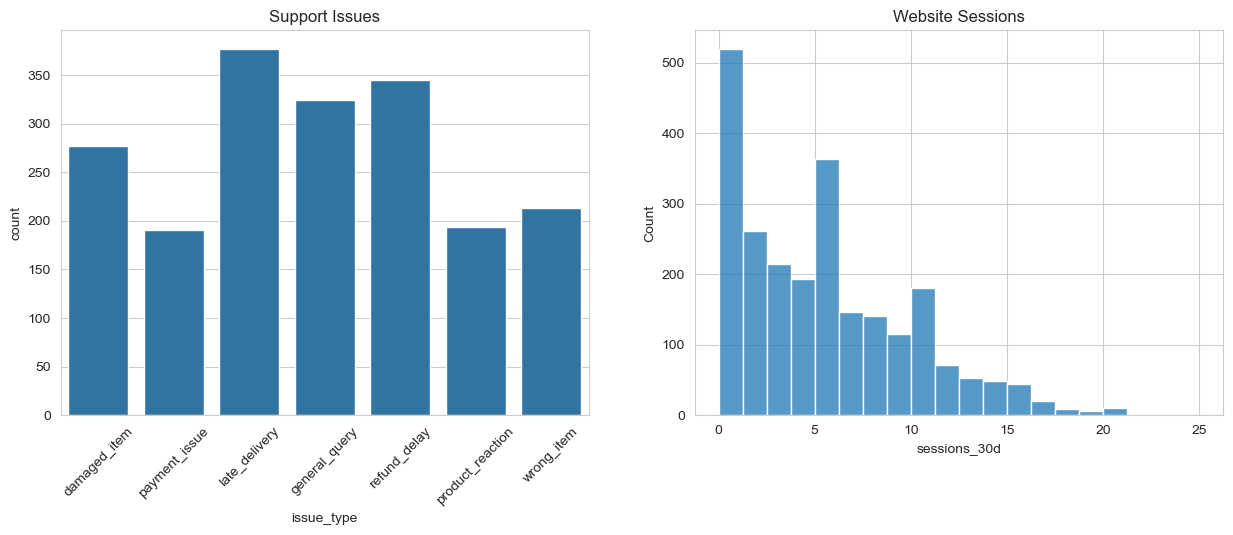

In [15]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(
    data=support,
    x="issue_type",
    ax=axes[0]
)

axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Support Issues")

sns.histplot(
    web["sessions_30d"],
    bins=20,
    ax=axes[1]
)

axes[1].set_title("Website Sessions")

plt.show()

# Campaign and return analysis

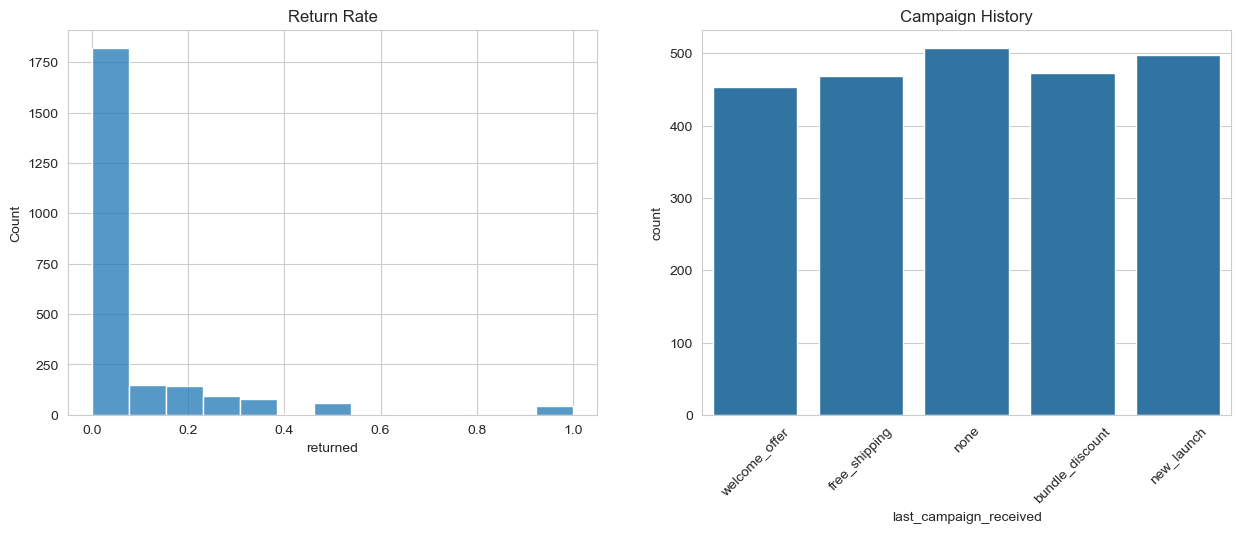

In [16]:
return_rate = (
    orders.groupby("customer_id")
    ["returned"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.histplot(
    return_rate["returned"],
    ax=axes[0]
)

axes[0].set_title("Return Rate")

sns.countplot(
    data=intervention,
    x="last_campaign_received",
    ax=axes[1]
)

axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Campaign History")

plt.show()

# Churn risk Hypothesis

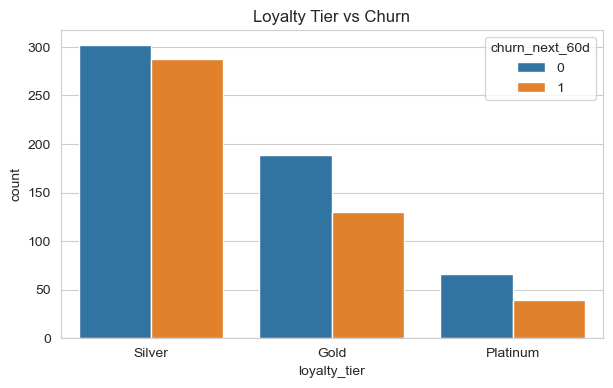

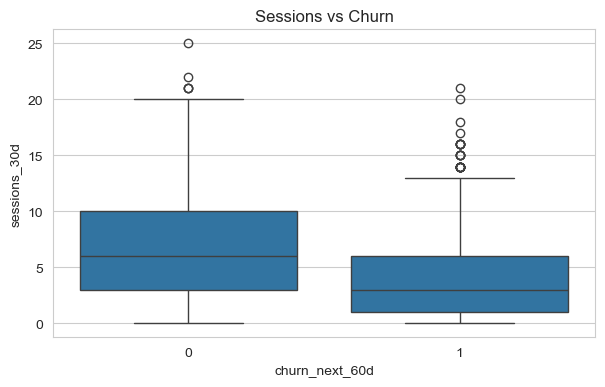

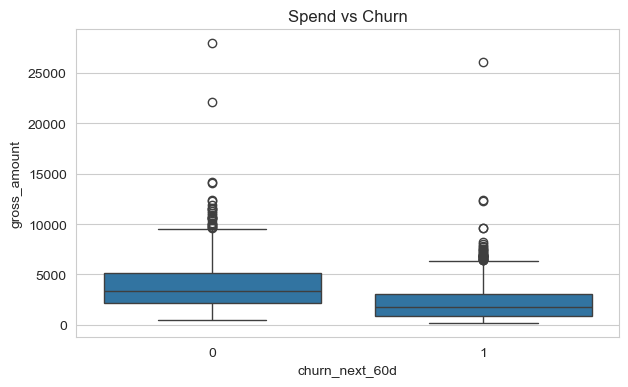

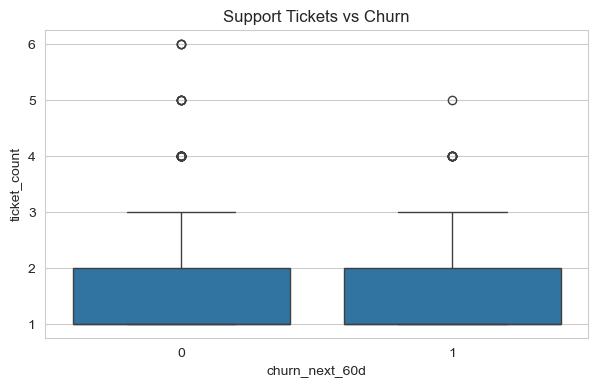

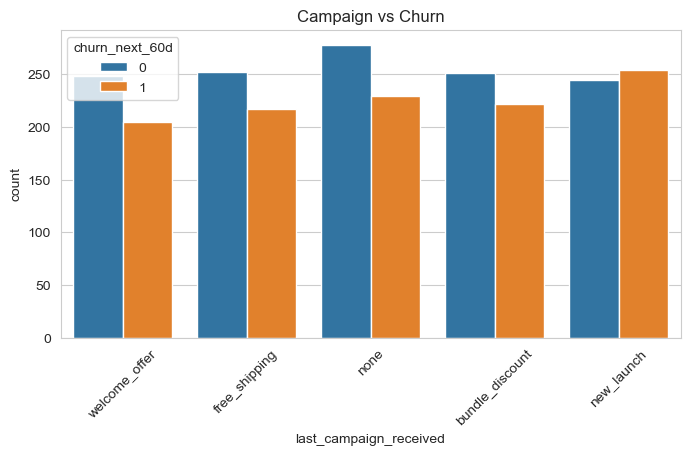

In [17]:
# loyalty vs churn
merged = customers.merge(
    churn,
    on="customer_id"
)

plt.figure(figsize=(7,4))

sns.countplot(
    data=merged,
    x="loyalty_tier",
    hue="churn_next_60d"
)

plt.title("Loyalty Tier vs Churn")
plt.show()

# sessions vs churn
activity = web.merge(
    churn,
    on="customer_id"
)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=activity,
    x="churn_next_60d",
    y="sessions_30d"
)

plt.title("Sessions vs Churn")
plt.show()

# spend vs churn
order_churn = (
    orders.groupby("customer_id")
    ["gross_amount"]
    .sum()
    .reset_index()
)

order_churn = order_churn.merge(
    churn,
    on="customer_id"
)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=order_churn,
    x="churn_next_60d",
    y="gross_amount"
)

plt.title("Spend vs Churn")
plt.show()

# support tickets vs churn
ticket_count = (
    support.groupby("customer_id")
    ["ticket_id"]
    .count()
    .reset_index(name="ticket_count")
)

ticket_count = ticket_count.merge(
    churn,
    on="customer_id"
)

plt.figure(figsize=(7,4))

sns.boxplot(
    data=ticket_count,
    x="churn_next_60d",
    y="ticket_count"
)

plt.title("Support Tickets vs Churn")
plt.show()

# campaign vs churn
campaign = intervention.merge(
    churn,
    on="customer_id"
)

plt.figure(figsize=(8,4))

sns.countplot(
    data=campaign,
    x="last_campaign_received",
    hue="churn_next_60d"
)

plt.xticks(rotation=45)

plt.title("Campaign vs Churn")
plt.show()

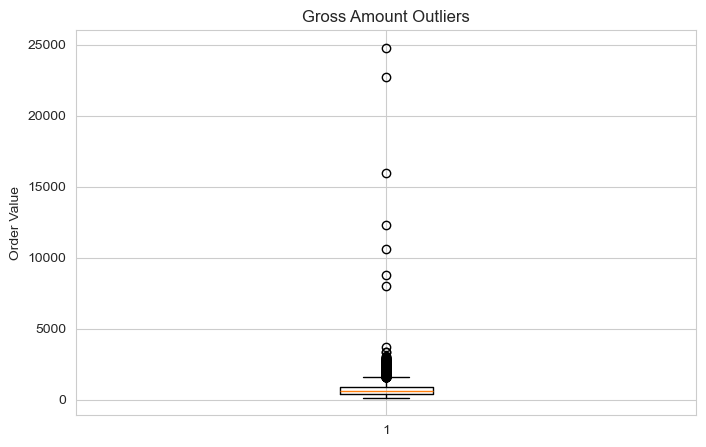

Outlier count: 536


In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(orders['gross_amount'])
plt.title("Gross Amount Outliers")
plt.ylabel("Order Value")
plt.show()

# IQR method
Q1 = orders['gross_amount'].quantile(0.25)
Q3 = orders['gross_amount'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + (1.5 * IQR)

outliers = orders[
    orders['gross_amount'] > upper_bound
]

print("Outlier count:", outliers.shape[0])

# Final Observation

In [18]:
import os

os.makedirs("outputs", exist_ok=True)

print("BUSINESS OBSERVATIONS")

# observation 1
avg_sessions = (
    activity.groupby("churn_next_60d")
    ["sessions_30d"]
    .mean()
)

if avg_sessions[1] < avg_sessions[0]:
    print("\n1. Churned customers show lower website activity, suggesting engagement drops before churn.")

# observation 2
loyalty_churn = pd.crosstab(
    merged["loyalty_tier"],
    merged["churn_next_60d"],
    normalize="index"
)

print("\n2. Customers enrolled in loyalty programs appear to retain better than customers without loyalty membership.")

# observation 3
avg_spend = (
    order_churn.groupby("churn_next_60d")
    ["gross_amount"]
    .mean()
)

if avg_spend[1] < avg_spend[0]:
    print("\n3. Customers with lower overall spending are more likely to churn.")

# observation 4
avg_tickets = (
    ticket_count.groupby("churn_next_60d")
    ["ticket_count"]
    .mean()
)

if avg_tickets[1] > avg_tickets[0]:
    print("\n4. Customers raising more support tickets may indicate dissatisfaction and higher churn risk.")

# observation 5
return_rate = (
    orders.groupby("customer_id")
    ["returned"]
    .mean()
    .reset_index()
)

avg_return = return_rate["returned"].mean()

print("\n5. High product return behaviour may signal weak product satisfaction and future churn risk.")

# observation 6
campaign_churn = pd.crosstab(
    campaign["last_campaign_received"],
    campaign["churn_next_60d"],
    normalize="index"
)

print("\n6. Some campaigns appear more effective than others and should be investigated before scaling retention efforts.")

# create output folder
os.makedirs("../outputs", exist_ok=True)

# save joined data
master.to_csv(
    "../outputs/joined_dataset_sample.csv",
    index=False
)

BUSINESS OBSERVATIONS

1. Churned customers show lower website activity, suggesting engagement drops before churn.

2. Customers enrolled in loyalty programs appear to retain better than customers without loyalty membership.

3. Customers with lower overall spending are more likely to churn.

5. High product return behaviour may signal weak product satisfaction and future churn risk.

6. Some campaigns appear more effective than others and should be investigated before scaling retention efforts.
